In [28]:
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import requests
import re
import urllib.parse
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path
from io import StringIO
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.preprocessing import MultiLabelBinarizer
from collections import Counter

In [29]:
# Year,Decade,Winner,Movie,IMDbRating,Runtime,Director,Actors,Writer(s),Distributor,Producer(s),Genre,BoxOffice

In [30]:
# film_df.tail()

In [41]:
# # Load your dataset
film_df = pd.read_csv("best_pic_nominees_winners.csv")

# # Create binary target: 1 if winner, 0 otherwise
# film_df['Winner'] = film_df['Winner'].astype(int)







# Fill missing values or drop rows/columns if necessary
# film_df = film_df.dropna(subset=['IMDbRating', 'Runtime', 'Genre'])

# def multi_hot_encode_column(df, column_name):
#     df[column_name] = df[column_name].fillna('').str.split(', ')
#     mlb = MultiLabelBinarizer()
#     encoded = pd.DataFrame(mlb.fit_transform(df[column_name]), columns=[f"{column_name}_{c}" for c in mlb.classes_], index=df.index)
#     return encoded

# # Apply to each relevant column
# genre_encoded = multi_hot_encode_column(film_df.copy(), 'Genre')
# actors_encoded = multi_hot_encode_column(film_df.copy(), 'Actors')
# writers_encoded = multi_hot_encode_column(film_df.copy(), 'Writer(s)')
# producers_encoded = multi_hot_encode_column(film_df.copy(), 'Producer(s)')

# # Combine all
# film_df = pd.concat([film_df, genre_encoded, actors_encoded, writers_encoded, producers_encoded], axis=1)



# def multi_hot_encode_top_n(df, column_name, top_n=20):
#     # Step 1: Split values into lists
#     df[column_name] = df[column_name].fillna('').str.split(', ')
    
#     # Step 2: Count frequency of each item
#     all_items = [item for sublist in df[column_name] for item in sublist]
#     top_items = set([item for item, count in Counter(all_items).most_common(top_n)])
    
#     # Step 3: Filter to only top N in each row
#     df[column_name + '_filtered'] = df[column_name].apply(lambda lst: [item for item in lst if item in top_items])
    
#     # Step 4: Multi-hot encode
#     mlb = MultiLabelBinarizer()
#     encoded = pd.DataFrame(mlb.fit_transform(df[column_name + '_filtered']),
#                            columns=[f"{column_name}_{c}" for c in mlb.classes_],
#                            index=df.index)
#     return encoded







# # Combine with original DataFrame
# df = pd.concat([df, genre_encoded], axis=1)

# # One-hot encode categorical features
# df_encoded = pd.get_dummies(film_df, columns=['Genre', 'Distributor', 'Director', 'Actors', 'Writer(s)', 'Producer(s)'], drop_first=True)

# # Select features for the model
# features = ['IMDbRating', 'Runtime'] + [col for col in df_encoded.columns if 'Genre_' in col or 'Distributor_' in col]
# X = df_encoded[features]
# y = df_encoded['Winner']

In [32]:
# actors_encoded = multi_hot_encode_top_n(film_df.copy(), 'Actors', top_n=30)
# writers_encoded = multi_hot_encode_top_n(film_df.copy(), 'Writer(s)', top_n=20)
# producers_encoded = multi_hot_encode_top_n(film_df.copy(), 'Producer(s)', top_n=20)

# # (Assuming Genre stays fully encoded as before)
# genre_encoded = multi_hot_encode_top_n(film_df.copy(), 'Genre', top_n=15)  # optional!

# # Combine all into one
# film_df = pd.concat([film_df, genre_encoded, actors_encoded, writers_encoded, producers_encoded], axis=1)


In [33]:
# feature_cols = (
#     list(genre_encoded.columns) +
#     list(actors_encoded.columns) +
#     list(writers_encoded.columns) +
#     list(producers_encoded.columns) +
#     ['IMDbRating', 'Runtime']  # add numerical features if desired
# )

# X = film_df[feature_cols]
# y = film_df['Winner']

# # Handle any missing values
# X = X.fillna(0)

# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Fit logistic regression
# log_model = LogisticRegression(max_iter=1000)
# log_model.fit(X_train, y_train)

# # Evaluate
# y_pred_log = log_model.predict(X_test)
# print("Logistic Regression Report:")
# print(classification_report(y_test, y_pred_log))

In [34]:
# # Get coefficients and match to feature names
# coefficients = pd.Series(log_model.coef_[0], index=X.columns)

# # Sort by magnitude (absolute value) to see most influential features
# coefficients_sorted = coefficients.reindex(coefficients.abs().sort_values(ascending=False).index)

# # Show top 20 (or however many you like)
# print(coefficients_sorted.head(20))

In [35]:
# # Assuming `coefficients` is your Series of model coefficients
# top_positive = coefficients.sort_values(ascending=False).head(10)
# top_negative = coefficients.sort_values().head(10)

# # Use pd.concat instead of append
# top_features = pd.concat([top_positive, top_negative])

# # Plot
# plt.figure(figsize=(10, 6))
# sns.barplot(x=top_features.values, y=top_features.index, palette="coolwarm")
# plt.title("Top Positive & Negative Predictors of Best Picture Win")
# plt.xlabel("Logistic Regression Coefficient")
# plt.tight_layout()
# plt.show()

In [36]:
# film_df.head(10)

In [37]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
# X_train = X_train.dropna()
# y_train = y_train[X_train.index]  # align target with filtered features

# X_test = X_test.dropna()
# y_test = y_test[X_test.index]

In [39]:
# log_model = LogisticRegression(max_iter=1000)
# log_model.fit(X_train, y_train)

# y_pred_log = log_model.predict(X_test)

# print("Logistic Regression Report:")
# print(classification_report(y_test, y_pred_log))

In [40]:
# coeffs = pd.Series(log_model.coef_[0], index=X.columns)
# print(coeffs.sort_values(ascending=False))

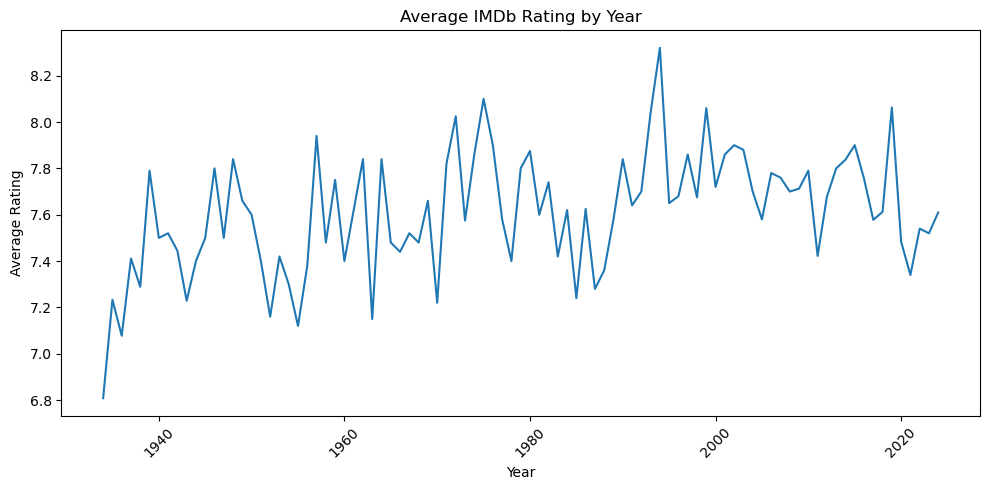

In [48]:
# By Year
rating_by_year = film_df.groupby("Year")["IMDbRating"].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(data=rating_by_year)
plt.title("Average IMDb Rating by Year")
plt.ylabel("Average Rating")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


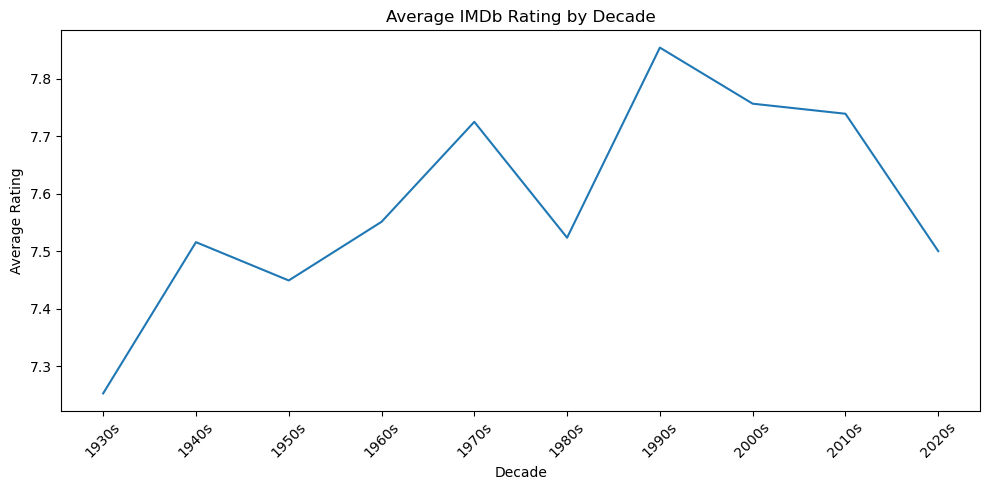

In [44]:
# By Decade
rating_by_decade = film_df.groupby("Decade")["IMDbRating"].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(data=rating_by_decade)
plt.title("Average IMDb Rating by Decade")
plt.ylabel("Average Rating")
plt.xlabel("Decade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

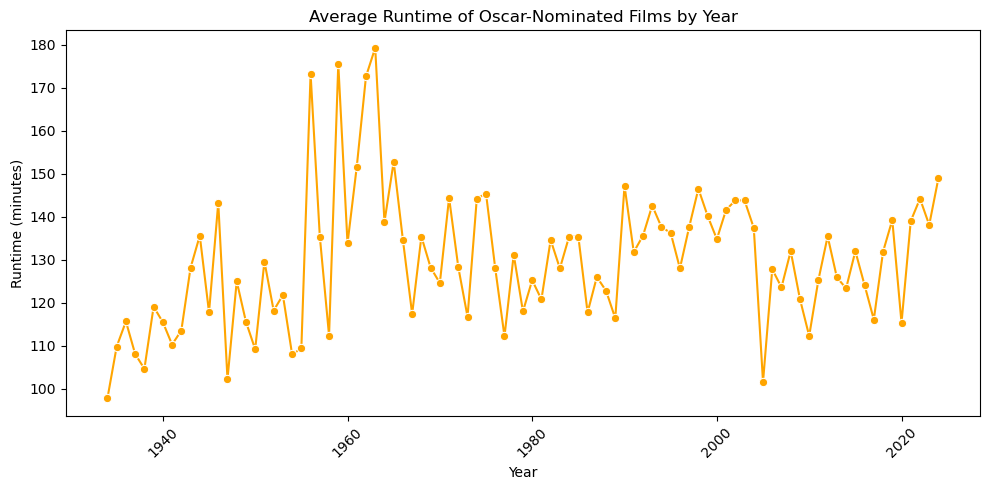

In [47]:
runtime_by_year = film_df.groupby("Year")["Runtime"].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(data=runtime_by_year, marker="o", color="orange")
plt.title("Average Runtime of Oscar-Nominated Films by Year")
plt.ylabel("Runtime (minutes)")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

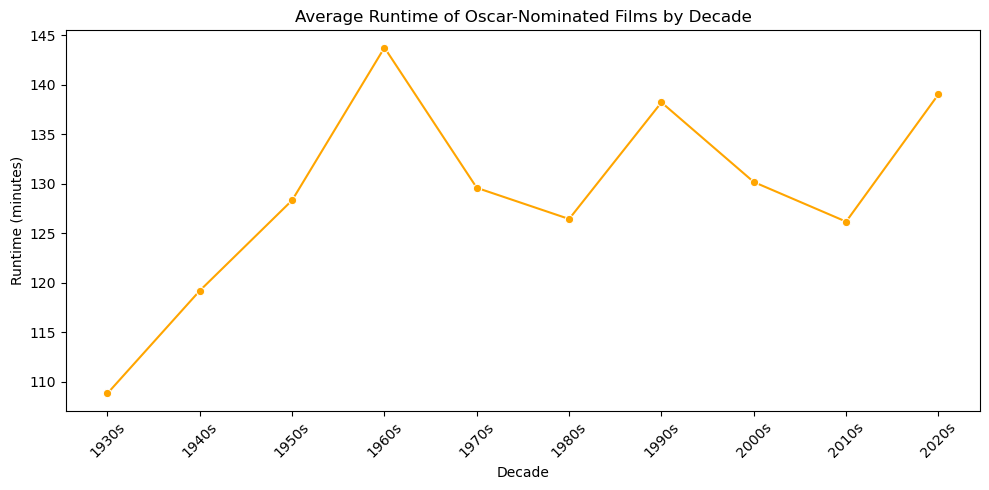

In [45]:
runtime_by_decade = film_df.groupby("Decade")["Runtime"].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(data=runtime_by_decade, marker="o", color="orange")
plt.title("Average Runtime of Oscar-Nominated Films by Decade")
plt.ylabel("Runtime (minutes)")
plt.xlabel("Decade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [52]:
def genre_counts(movies_df):
    exploded_genre = movies_df['Genre'].dropna().str.split(',').explode().str.strip()
    return exploded_genre.value_counts()


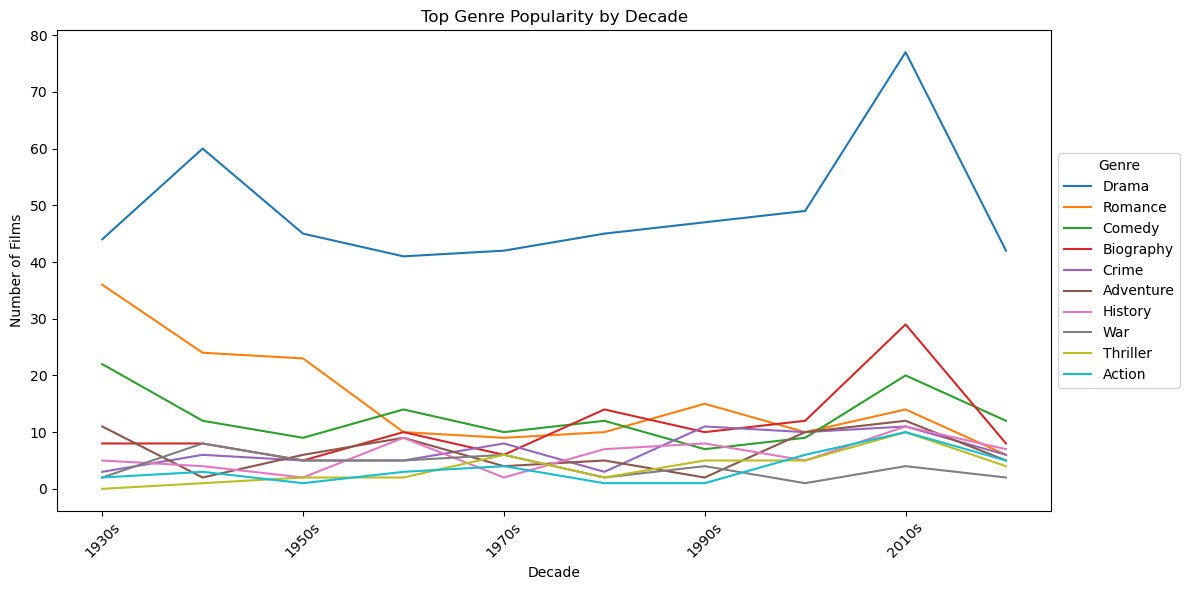

In [ ]:
top_genres = genre_counts(film_df).head(10).index.tolist()

genre_by_decade = {}

for decade, group in film_df.groupby("Decade"):
    exploded = group['Genre'].dropna().str.split(',').explode().str.strip()
    filtered = exploded[exploded.isin(top_genres)]
    genre_counts_decade = Counter(filtered)
    genre_by_decade[decade] = genre_counts_decade

genre_trend_df = pd.DataFrame(genre_by_decade).fillna(0).astype(int).T

genre_trend_df[top_genres].plot(kind="line", figsize=(12, 6))
plt.title("Top Genre Popularity by Decade")
plt.ylabel("Number of Films")
plt.xlabel("Decade")
plt.xticks(rotation=45)
plt.legend(title="Genre", loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()
